# Build and explore decision tree classifiers on the branchwater search output

In [154]:
# base checkout of workflow directory is here:
BASE='/Users/t/dev/2025-workflow-core99/'

# parquet files from branchwater
#BASE_OUTPUTS=BASE+'/outputs.branchwater'

MIN=90
SCALED=1000
HASH_THRESHOLD=int(20000 / SCALED)

#BASE_OUTPUTS=BASE+f'/outputs.mapping/cds/singlehash.k21/outputs.branchwater.min{MIN}.scaled{SCALED}'
BASE_OUTPUTS=BASE+'/outputs.mapping/cds2/outputs.branchwater'

In [155]:
import polars as pl
import numpy as np
import sklearn.tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import scipy.spatial.distance
import seaborn as sns
from matplotlib import pyplot as plt

## Load in all the data & filter at HASH_THRESHOLD

In [156]:
dirpath = BASE_OUTPUTS+'/*.parquet'

bw_df = pl.scan_parquet(dirpath).collect()
bw_df = bw_df.with_columns(pl.col("query_name").alias("species"),
                           pl.col("match_name").alias("acc"))
bw_df = bw_df.select(["species", "acc", "containment", "intersect_hashes"])

before_threshold = set(bw_df['species'].unique())

# mimic the Web site search threshold of 0.1
bw_df = bw_df.filter(pl.col("intersect_hashes") >= HASH_THRESHOLD)

after_threshold = set(bw_df['species'].unique())

print('lost:', before_threshold - after_threshold)

lost: {'s__UBA2868 sp004552595', 's__Holdemanella porci'}


## Load in metadata, select for valid accessions and WGS

In [157]:
metadata_df = pl.scan_parquet('/Users/t/dev/2025-workflow-core99/20241128-metadata.parquet')
metadata_df = metadata_df.select(["acc", "organism", "assay_type", "bioproject"])\
    .filter(pl.col("acc") != "NP")\
    .filter(pl.col("assay_type") == "WGS")

metadata_df = metadata_df.collect()
metadata_df

acc,organism,assay_type,bioproject
str,str,str,str
"""SRR28523869""","""human metagenome""","""WGS""","""PRJNA1095378"""
"""SRR19901137""","""Streptococcus suis""","""WGS""","""PRJNA854064"""
"""SRR24962475""","""Escherichia coli""","""WGS""","""PRJNA982891"""
"""SRR29161330""","""biofilm metagenome""","""WGS""","""PRJNA1116137"""
"""SRR26668739""","""bovine gut metagenome""","""WGS""","""PRJNA1035769"""
…,…,…,…
"""ERR4174288""","""human gut metagenome""","""WGS""","""PRJEB36461"""
"""ERR3160109""","""human gut metagenome""","""WGS""","""PRJEB23292"""
"""ERR2709457""","""human gut metagenome""","""WGS""","""PRJEB27799"""


In [201]:
bw_df = bw_df.join(metadata_df, on="acc", how="inner")
bw_df

acc,organism,species,simpleorg,organism_right,assay_type,bioproject
str,str,str,str,str,str,str
"""SRR17241670""","""pig gut metagenome""","""s__Bariatricus sp004560705""","""pig""","""pig gut metagenome""","""WGS""","""PRJNA788462"""
"""SRR17241692""","""pig gut metagenome""","""s__Bariatricus sp004560705""","""pig""","""pig gut metagenome""","""WGS""","""PRJNA788462"""
"""SRR23223860""","""pig gut metagenome""","""s__Bariatricus sp004560705""","""pig""","""pig gut metagenome""","""WGS""","""PRJNA926485"""
"""SRR30884442""","""feces metagenome""","""s__Bariatricus sp004560705""","""unknown""","""feces metagenome""","""WGS""","""PRJNA1163957"""
"""SRR30884443""","""feces metagenome""","""s__Bariatricus sp004560705""","""unknown""","""feces metagenome""","""WGS""","""PRJNA1163957"""
…,…,…,…,…,…,…
"""ERR6590002""","""mouse gut metagenome""","""s__Sodaliphilus sp004557565""","""unknown""","""mouse gut metagenome""","""WGS""","""PRJEB47257"""
"""SRR2244710""","""gut metagenome""","""s__Sodaliphilus sp004557565""","""unknown""","""gut metagenome""","""WGS""","""PRJNA217052"""
"""SRR15244446""","""human gut metagenome""","""s__Sodaliphilus sp004557565""","""human""","""human gut metagenome""","""WGS""","""PRJNA749645"""


In [202]:
bw_df['organism'].value_counts().sort(by='count', descending=True)

organism,count
str,u32
"""human gut metagenome""",560012
"""gut metagenome""",133499
"""metagenome""",111990
"""pig gut metagenome""",63982
"""human metagenome""",48748
…,…
"""protist metagenome""",1
"""human eye metagenome""",1
"""steel metagenome""",1


## Build a new dataframe, 'simpleorg', that is just three values: human, pig, other.

In [203]:
rename_df = []
for organism in bw_df['organism'].unique().to_list():
    simpleorg = 'unknown'
    if organism:
        organism = organism.lower()
        for kw in ['human', 'homo']:
            if kw in organism.lower():
                simpleorg = 'human'
                break
        for kw in ['pig', 'sus', 'scrofa']:
            if kw in organism.lower():
                simpleorg = 'pig'
                break
    rename_df.append(dict(organism=organism, simpleorg=simpleorg))

rename_df = pl.DataFrame(rename_df)
rename_df['simpleorg'].value_counts().sort(by='count', descending=True)


simpleorg,count
str,u32
"""unknown""",215
"""human""",17
"""pig""",2


In [204]:
rename_df

organism,simpleorg
str,str
"""microbial eukaryotic metagenom…","""unknown"""
"""symbiont metagenome""","""unknown"""
"""epibiont metagenome""","""unknown"""
"""mollusc metagenome""","""unknown"""
"""cow dung metagenome""","""unknown"""
…,…
"""metagenomes""","""unknown"""
"""steel metagenome""","""unknown"""
"""riverine metagenome""","""unknown"""


## Add a new column, `simpleorg`, to the branchwater output.

In [205]:
bw_df

acc,organism,species,simpleorg,organism_right,assay_type,bioproject
str,str,str,str,str,str,str
"""SRR17241670""","""pig gut metagenome""","""s__Bariatricus sp004560705""","""pig""","""pig gut metagenome""","""WGS""","""PRJNA788462"""
"""SRR17241692""","""pig gut metagenome""","""s__Bariatricus sp004560705""","""pig""","""pig gut metagenome""","""WGS""","""PRJNA788462"""
"""SRR23223860""","""pig gut metagenome""","""s__Bariatricus sp004560705""","""pig""","""pig gut metagenome""","""WGS""","""PRJNA926485"""
"""SRR30884442""","""feces metagenome""","""s__Bariatricus sp004560705""","""unknown""","""feces metagenome""","""WGS""","""PRJNA1163957"""
"""SRR30884443""","""feces metagenome""","""s__Bariatricus sp004560705""","""unknown""","""feces metagenome""","""WGS""","""PRJNA1163957"""
…,…,…,…,…,…,…
"""ERR6590002""","""mouse gut metagenome""","""s__Sodaliphilus sp004557565""","""unknown""","""mouse gut metagenome""","""WGS""","""PRJEB47257"""
"""SRR2244710""","""gut metagenome""","""s__Sodaliphilus sp004557565""","""unknown""","""gut metagenome""","""WGS""","""PRJNA217052"""
"""SRR15244446""","""human gut metagenome""","""s__Sodaliphilus sp004557565""","""human""","""human gut metagenome""","""WGS""","""PRJNA749645"""


In [206]:
# add a new column with a simplified organism
bw_df = bw_df.join(rename_df, on='organism', how='inner', coalesce=True).select(['acc', 'organism', 'species', 'simpleorg', 'bioproject'])
bw_df.select(['acc', 'simpleorg']).unique()['simpleorg'].value_counts()


simpleorg,count
str,u32
"""unknown""",147370
"""human""",163451
"""pig""",6923


In [207]:
bw_df

acc,organism,species,simpleorg,bioproject
str,str,str,str,str
"""SRR17241670""","""pig gut metagenome""","""s__Bariatricus sp004560705""","""pig""","""PRJNA788462"""
"""SRR17241692""","""pig gut metagenome""","""s__Bariatricus sp004560705""","""pig""","""PRJNA788462"""
"""SRR23223860""","""pig gut metagenome""","""s__Bariatricus sp004560705""","""pig""","""PRJNA926485"""
"""SRR30884442""","""feces metagenome""","""s__Bariatricus sp004560705""","""unknown""","""PRJNA1163957"""
"""SRR30884443""","""feces metagenome""","""s__Bariatricus sp004560705""","""unknown""","""PRJNA1163957"""
…,…,…,…,…
"""ERR6590002""","""mouse gut metagenome""","""s__Sodaliphilus sp004557565""","""unknown""","""PRJEB47257"""
"""SRR2244710""","""gut metagenome""","""s__Sodaliphilus sp004557565""","""unknown""","""PRJNA217052"""
"""SRR15244446""","""human gut metagenome""","""s__Sodaliphilus sp004557565""","""human""","""PRJNA749645"""


## Set up for classifier work - `make_matrices`

Create a function that takes a dataframe with `acc`, `species`, and `simpleorg`, and builds numpy matrices
suitable for scikit-learn classifers.

In [208]:
def make_matrices(df):
    acc_df = df['acc'].unique().to_frame().sort(by='acc').with_row_index(name='acc_index')
    species_df = df['species'].unique().to_frame().sort(by='species').with_row_index(name='species_index')
    org_df = df['simpleorg'].unique().to_frame().sort(by='simpleorg').with_row_index(name='org_index')

    df = df.join(org_df, on='simpleorg', how='left')
    df = df.join(acc_df, on='acc', how='left')
    df = df.join(species_df, on='species', how='left')

    obs = np.zeros((len(acc_df), len(species_df)))
    target = np.zeros((len(acc_df)))

    for row in df.iter_rows(named=True):
        acc_id = row["acc_index"]
        org_id = row["org_index"]
        species_id = row["species_index"]

        obs[acc_id, species_id] = 1
        target[acc_id] = org_id

    print(f'observations matrix shape is: {obs.shape}')

    return df, obs, target


### Build another function that returns a distance matrix between the columns

Default metric: cosine; support others such as Jaccard.

In [209]:
def make_col_dist(mat, *, metric='cosine'):
    n_col = mat.shape[1]
    col_dist = np.ones((n_col, n_col))

    distf = getattr(scipy.spatial.distance, metric)
    for i in range(n_col):
        for j in range(i):
            d = distf(mat[:,i], mat[:,j])
            col_dist[i, j] = d
            col_dist[j, i] = d
        col_dist[i, i] = 0
    
    col_dist = 1 - col_dist
    return col_dist

## Explore frequencies of & correlations between species metrics in datasets of different types

### Human + pig only

In [210]:
human_pig_only = bw_df.filter(pl.col("simpleorg") != "unknown")
hp_df, hp_obs, hp_target = make_matrices(human_pig_only)
print(f'made matrices for {len(human_pig_only)} rows, {hp_obs.shape[1]} species')

observations matrix shape is: (170374, 13)
made matrices for 697360 rows, 13 species


observations matrix shape is: (170374, 13)


Text(0.5, 1.0, 'species correlation across 170374 human/pig metagenomes')

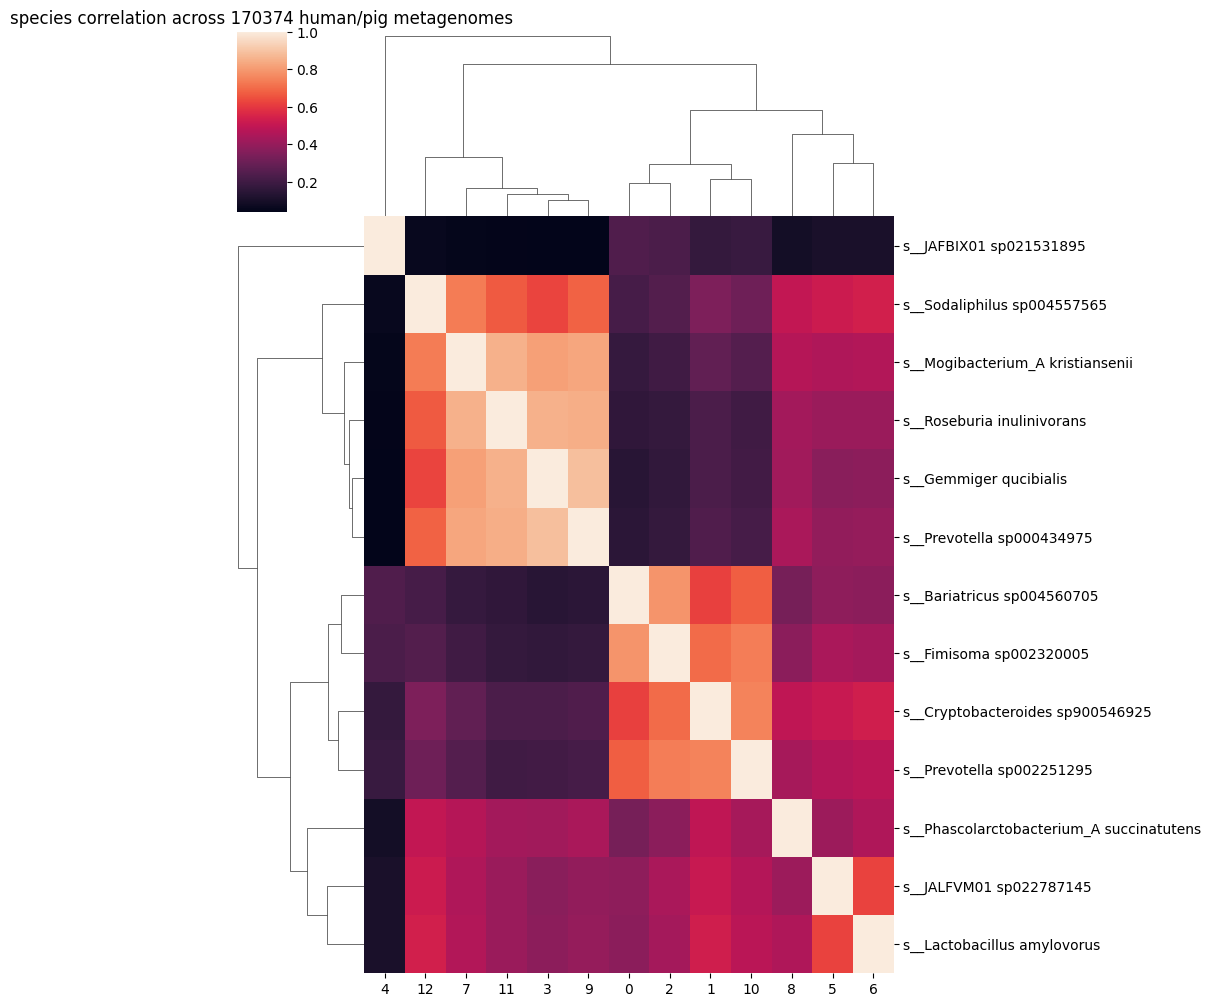

In [211]:
human_pig_only = bw_df.filter(pl.col("simpleorg") != "unknown")
hp_df, hp_obs, hp_target = make_matrices(human_pig_only)

hp_col_dist = make_col_dist(hp_obs)
hp_labels = hp_df.select(['species_index', 'species']).unique().sort(by='species_index')['species'].to_list()
sns.clustermap(hp_col_dist, yticklabels=hp_labels)
plt.title(f"species correlation across {hp_df['acc'].n_unique()} human/pig metagenomes")

### Pig only

observations matrix shape is: (6923, 13)


Text(0.5, 1.0, 'species correlation across 6923 pig metagenomes')

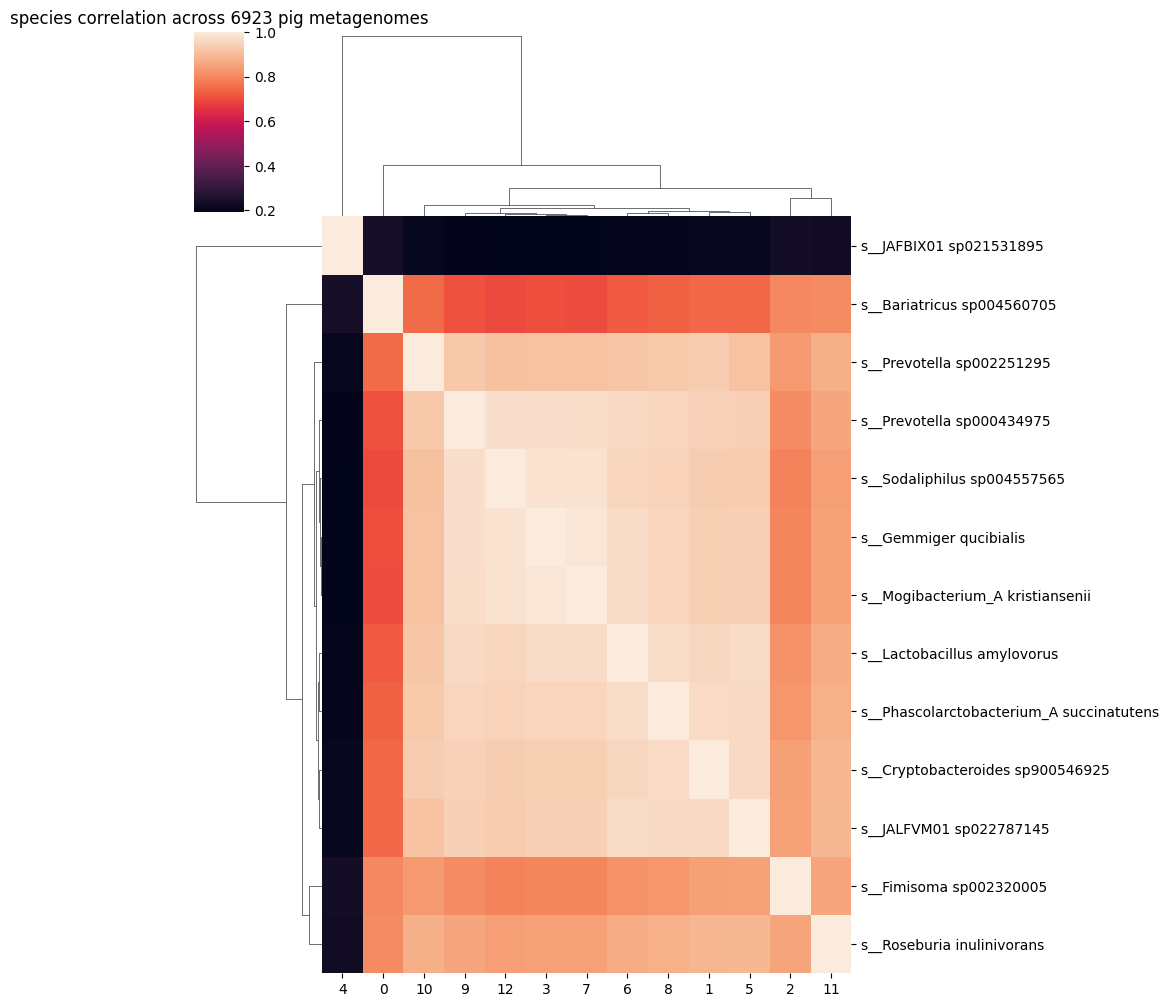

In [212]:
pig_only = bw_df.filter(pl.col("simpleorg") == "pig")
pig_df, pig_obs, pig_target = make_matrices(pig_only)

pig_col_dist = make_col_dist(pig_obs)
pig_labels = pig_df.select(['species_index', 'species']).unique().sort(by='species_index')['species'].to_list()
sns.clustermap(pig_col_dist, yticklabels=pig_labels)
plt.title(f"species correlation across {pig_df['acc'].n_unique()} pig metagenomes")

### Frequencies of species in pig

In [213]:
total_accs = pig_df['acc'].n_unique()
freq_pig_df = pig_df.group_by('species').agg((pl.col("acc").len() / total_accs).alias("pig_freq")).sort(by='pig_freq', descending=True)

with pl.Config(tbl_rows=-1):
    print(freq_pig_df)

shape: (13, 2)
┌─────────────────────────────────┬──────────┐
│ species                         ┆ pig_freq │
│ ---                             ┆ ---      │
│ str                             ┆ f64      │
╞═════════════════════════════════╪══════════╡
│ s__Sodaliphilus sp004557565     ┆ 0.974577 │
│ s__Mogibacterium_A kristiansen… ┆ 0.964611 │
│ s__Gemmiger qucibialis          ┆ 0.961866 │
│ s__Prevotella sp000434975       ┆ 0.93861  │
│ s__Lactobacillus amylovorus     ┆ 0.910443 │
│ s__Phascolarctobacterium_A suc… ┆ 0.87881  │
│ s__JALFVM01 sp022787145         ┆ 0.853098 │
│ s__Cryptobacteroides sp9005469… ┆ 0.849921 │
│ s__Prevotella sp002251295       ┆ 0.810487 │
│ s__Roseburia inulinivorans      ┆ 0.69103  │
│ s__Fimisoma sp002320005         ┆ 0.610862 │
│ s__Bariatricus sp004560705      ┆ 0.472194 │
│ s__JAFBIX01 sp021531895         ┆ 0.036256 │
└─────────────────────────────────┴──────────┘


### Human only

observations matrix shape is: (163451, 12)


Text(0.5, 1.0, 'species correlation across 163451 human metagenomes')

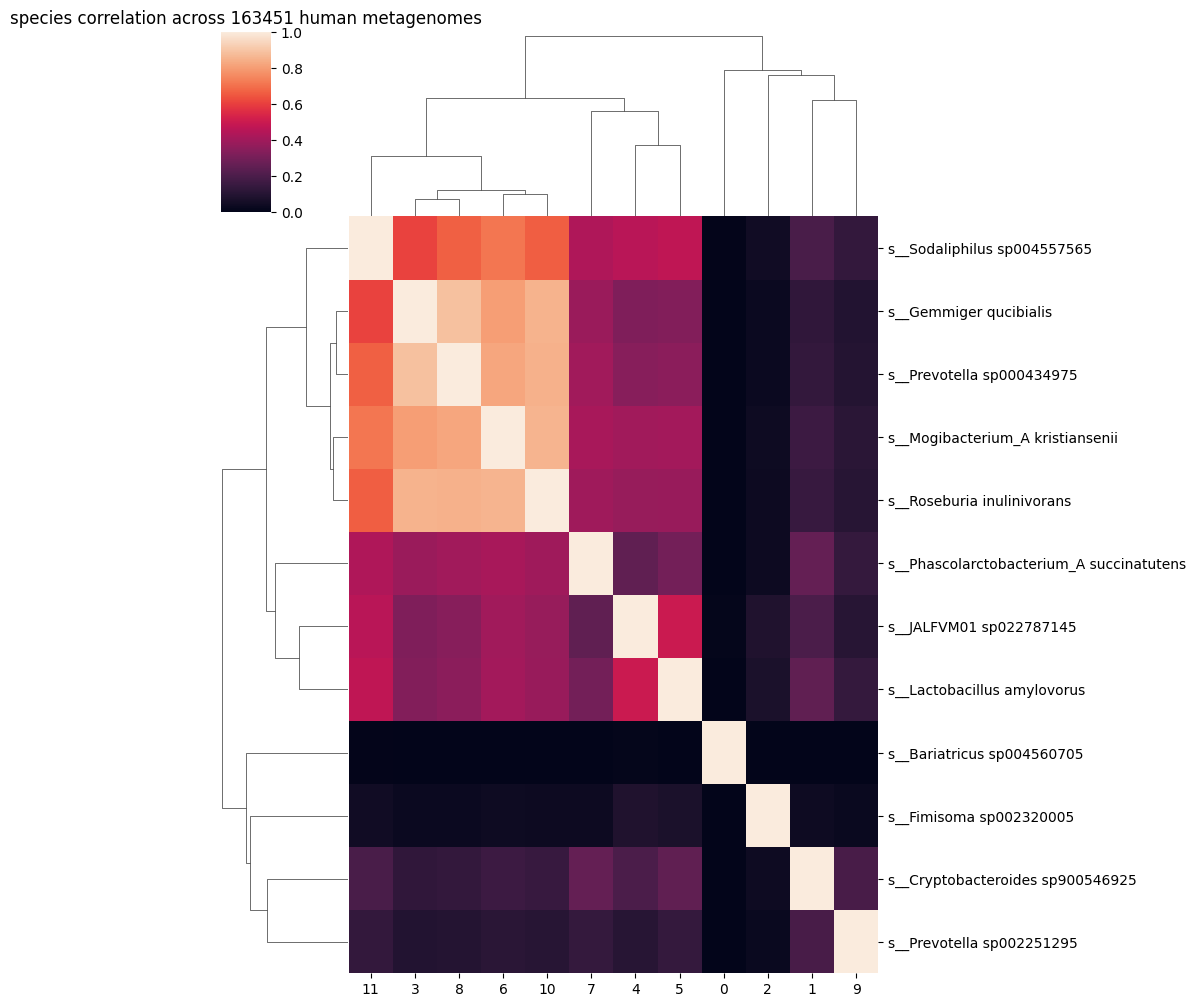

In [214]:
human_only = bw_df.filter(pl.col("simpleorg") == "human")
human_df, human_obs, human_target = make_matrices(human_only)

human_col_dist = make_col_dist(human_obs)
human_labels = human_df.select(['species_index', 'species']).unique().sort(by='species_index')['species'].to_list()

sns.clustermap(human_col_dist, yticklabels=human_labels)

plt.title(f"species correlation across {human_df['acc'].n_unique()} human metagenomes")

### Frequencies of species in human only

In [215]:
total_accs = human_df['acc'].n_unique()
freq_human_df = human_df.group_by('species').agg((pl.col("acc").len() / total_accs).alias("human_freq")).sort(by='human_freq', descending=True)

with pl.Config(tbl_rows=-1):
    print(freq_human_df)

shape: (12, 2)
┌─────────────────────────────────┬────────────┐
│ species                         ┆ human_freq │
│ ---                             ┆ ---        │
│ str                             ┆ f64        │
╞═════════════════════════════════╪════════════╡
│ s__Gemmiger qucibialis          ┆ 0.942466   │
│ s__Prevotella sp000434975       ┆ 0.834434   │
│ s__Roseburia inulinivorans      ┆ 0.69619    │
│ s__Mogibacterium_A kristiansen… ┆ 0.61449    │
│ s__Sodaliphilus sp004557565     ┆ 0.38715    │
│ s__Phascolarctobacterium_A suc… ┆ 0.143358   │
│ s__Lactobacillus amylovorus     ┆ 0.103817   │
│ s__JALFVM01 sp022787145         ┆ 0.098874   │
│ s__Cryptobacteroides sp9005469… ┆ 0.015381   │
│ s__Prevotella sp002251295       ┆ 0.007972   │
│ s__Fimisoma sp002320005         ┆ 0.000789   │
│ s__Bariatricus sp004560705      ┆ 0.000006   │
└─────────────────────────────────┴────────────┘


## Frequencies of species in pig _compared_ to human

In [216]:
with pl.Config(tbl_rows=-1):
    print(freq_human_df.join(freq_pig_df, on='species'))

shape: (12, 3)
┌─────────────────────────────────┬────────────┬──────────┐
│ species                         ┆ human_freq ┆ pig_freq │
│ ---                             ┆ ---        ┆ ---      │
│ str                             ┆ f64        ┆ f64      │
╞═════════════════════════════════╪════════════╪══════════╡
│ s__Sodaliphilus sp004557565     ┆ 0.38715    ┆ 0.974577 │
│ s__Mogibacterium_A kristiansen… ┆ 0.61449    ┆ 0.964611 │
│ s__Gemmiger qucibialis          ┆ 0.942466   ┆ 0.961866 │
│ s__Prevotella sp000434975       ┆ 0.834434   ┆ 0.93861  │
│ s__Lactobacillus amylovorus     ┆ 0.103817   ┆ 0.910443 │
│ s__Phascolarctobacterium_A suc… ┆ 0.143358   ┆ 0.87881  │
│ s__JALFVM01 sp022787145         ┆ 0.098874   ┆ 0.853098 │
│ s__Cryptobacteroides sp9005469… ┆ 0.015381   ┆ 0.849921 │
│ s__Prevotella sp002251295       ┆ 0.007972   ┆ 0.810487 │
│ s__Roseburia inulinivorans      ┆ 0.69619    ┆ 0.69103  │
│ s__Fimisoma sp002320005         ┆ 0.000789   ┆ 0.610862 │
│ s__Bariatricus sp004560

## 6-Fold Cross Validation approach

Run 6 different splits of the data; train on 1/6 of the data and test on the other 5/6s of the data, and then repeat that for each of the 6 splits.

In [217]:
kf = StratifiedKFold(n_splits=6)

accuracies = []
i = 1
for train_sub, test_sub in kf.split(hp_obs, hp_target):
    dt = DecisionTreeClassifier(random_state=42)
    tree = dt.fit(hp_obs[train_sub], hp_target[train_sub])
    pred = tree.predict(hp_obs[test_sub])

    accuracy = balanced_accuracy_score(hp_target[test_sub], pred, adjusted=True)
    accuracies.append(accuracy)
    print(f"iteration {i}: accuracy {accuracy:.3f}")
    print('xxx', roc_auc_score(hp_target[test_sub], pred))
    i += 1

print(f"mean accuracy across {i-1} splits: {np.mean(accuracies):.3f}")

iteration 1: accuracy 0.711
xxx 0.8552715204132878
iteration 2: accuracy 0.948
xxx 0.9742276269044753
iteration 3: accuracy 0.950
xxx 0.9748745342629647
iteration 4: accuracy 0.860
xxx 0.9300518734643226
iteration 5: accuracy 0.865
xxx 0.9323046564813414
iteration 6: accuracy 0.958
xxx 0.9788835064028589
mean accuracy across 6 splits: 0.882


## What do we after 6-fold cross validation?

This approach lets us check to see that, in general, the performance of any classifer trained on this data will be pretty good - independent of which set of data we use.

Now, to train the best possible classifier for _future_ use, we will use all the data to train:

In [218]:
dt = DecisionTreeClassifier(random_state=42)
tree = dt.fit(hp_obs, hp_target)
pred = tree.predict(hp_obs)

accuracy = balanced_accuracy_score(hp_target, pred, adjusted=True)

print(f"full classifier: accuracy {accuracy:.3f}")
print(f"full classifier: ROC AUC score: {roc_auc_score(hp_target, pred):.3f}")


full classifier: accuracy 0.910
full classifier: ROC AUC score: 0.955


## What do we do with the full classifier now??

Now we can go back to the original data - not just the human/pig subset, but the one with unknowns. (Or, potentially, new data sets.)

The only thing we need to be careful about is to encode new observations using the species indexes that match the trained classifier, as well as the organism indexes (0 pig, 1 human). Let's extract those:

In [219]:
species_index_df = hp_df.select(['species_index', 'species']).unique()
species_index_df

species_index,species
u32,str
3,"""s__Gemmiger qucibialis"""
10,"""s__Prevotella sp002251295"""
11,"""s__Roseburia inulinivorans"""
0,"""s__Bariatricus sp004560705"""
7,"""s__Mogibacterium_A kristiansen…"
…,…
1,"""s__Cryptobacteroides sp9005469…"
9,"""s__Prevotella sp000434975"""
12,"""s__Sodaliphilus sp004557565"""


In [220]:
org_df = hp_df.select(['org_index', 'simpleorg']).unique()
org_df

org_index,simpleorg
u32,str
1,"""pig"""
0,"""human"""


### Classify "other"/unknown

Now, let's take some of some of the data we didn't touch from the original bw_df, and encode and classify it: 

In [221]:
def make_obs_matrix(df, species_df):
    # need a new accession mapping
    acc_df = df['acc'].unique().to_frame().sort(by='acc').with_row_index(name='acc_index')

    # construct new internal data frame, populate
    df = df.join(acc_df, on='acc', how='left')
    df = df.join(species_df, on='species', how='left')

    obs = np.zeros((len(acc_df), len(species_df)))

    for row in df.iter_rows(named=True):
        acc_id = row["acc_index"]
        species_id = row["species_index"]

        obs[acc_id, species_id] = 1

    print(f'observations matrix shape is: {obs.shape}')

    return df, obs


In [222]:
unknown_only_df = bw_df.filter(pl.col("simpleorg") == "unknown")
unk_df, unk_obs = make_obs_matrix(unknown_only_df, species_index_df)

observations matrix shape is: (147370, 13)


In [223]:
unknown_pred = tree.predict(unk_obs)
unknown_pred

array([0., 0., 0., ..., 0., 0., 0.], shape=(147370,))

## Predictions are great and all but...

Great! Lots of predictions 😭 . What do we do with them??

Let's merge the predictions back into the unknown df.

In [224]:
unk_pred_df = []
for (row_n, predicted_org) in enumerate(unknown_pred):
    unk_pred_df.append(dict(acc_index=row_n, org_index=int(predicted_org)))
unk_pred_df = pl.DataFrame(unk_pred_df).join(org_df, on='org_index', how='left')

unk_acc_df = unk_df.select(["acc", "acc_index"]).unique()

unk_pred_df = unk_pred_df.join(unk_acc_df, on='acc_index', how='left')
unk_pred_df

acc_index,org_index,simpleorg,acc
i64,i64,str,str
0,0,"""human""","""DRR001462"""
1,0,"""human""","""DRR001464"""
2,0,"""human""","""DRR012573"""
3,0,"""human""","""DRR012574"""
4,0,"""human""","""DRR012575"""
…,…,…,…
147365,0,"""human""","""SRR9998341"""
147366,0,"""human""","""SRR9998342"""
147367,0,"""human""","""SRR9998343"""


In [225]:
unk_pred_df["simpleorg"].value_counts().sort(by='count', descending=True)

simpleorg,count
str,u32
"""human""",137897
"""pig""",9473


## OK! We have our predictions... did this actually work?

In [243]:
bw_df

acc,organism,species,simpleorg,bioproject
str,str,str,str,str
"""SRR17241670""","""pig gut metagenome""","""s__Bariatricus sp004560705""","""pig""","""PRJNA788462"""
"""SRR17241692""","""pig gut metagenome""","""s__Bariatricus sp004560705""","""pig""","""PRJNA788462"""
"""SRR23223860""","""pig gut metagenome""","""s__Bariatricus sp004560705""","""pig""","""PRJNA926485"""
"""SRR30884442""","""feces metagenome""","""s__Bariatricus sp004560705""","""unknown""","""PRJNA1163957"""
"""SRR30884443""","""feces metagenome""","""s__Bariatricus sp004560705""","""unknown""","""PRJNA1163957"""
…,…,…,…,…
"""ERR6590002""","""mouse gut metagenome""","""s__Sodaliphilus sp004557565""","""unknown""","""PRJEB47257"""
"""SRR2244710""","""gut metagenome""","""s__Sodaliphilus sp004557565""","""unknown""","""PRJNA217052"""
"""SRR15244446""","""human gut metagenome""","""s__Sodaliphilus sp004557565""","""human""","""PRJNA749645"""


In [253]:
curated_df = pl.read_csv('../inputs.branchwater/manual_curation_bioprj.done.2025-12-22.csv')
curated_df = curated_df.join(bw_df, on='bioproject', how='inner').select(['acc', 'manual_cur'])
unk_pred_df = unk_pred_df.join(curated_df, on='acc').select(['acc', 'simpleorg', 'manual_cur'])


In [260]:
# sample 5 randomly
unk_pred_df.sample(n=5)

acc,simpleorg,manual_cur
str,str,str
"""ERR1600573""","""human""","""human"""
"""SRR28432138""","""human""","""human"""
"""SRR15051531""","""human""","""human"""
"""SRR14863646""","""human""","""human"""
"""SRR29703649""","""human""","""human"""


In [261]:
# sample 5 predicted as pig
unk_pred_df.filter(pl.col("simpleorg") == "pig").sample(n=5)

acc,simpleorg,manual_cur
str,str,str
"""SRR3469671""","""pig""",null
"""ERR12660949""","""pig""","""human"""
"""SRR28746791""","""pig""","""human"""
"""ERR4833673""","""pig""","""unknown"""
"""SRR16020827""","""pig""","""cattle"""


In [262]:
# sample 5 predicted as human
unk_pred_df.filter(pl.col("simpleorg") == "human").sample(n=5)

acc,simpleorg,manual_cur
str,str,str
"""SRR2237341""","""human""","""mix"""
"""SRR27418719""","""human""","""human"""
"""ERR10610423""","""human""","""mouse"""
"""SRR25336579""","""human""","""human"""
"""ERR2902210""","""human""",null


# What features are most important for good classification?

First, let's get the feature importances.

In [231]:
importances_df = []
for (species_index, importance) in enumerate(tree.feature_importances_):
    d = dict(species_index=species_index, importance=importance)
    importances_df.append(d)

importances_df = pl.DataFrame(importances_df)
importances_df = importances_df.join(species_index_df, on='species_index', how='left')
importances_df = importances_df.sort(by='importance', descending=True)
importances_df

species_index,importance,species
i64,f64,str
10,0.735202,"""s__Prevotella sp002251295"""
1,0.110024,"""s__Cryptobacteroides sp9005469…"
11,0.048814,"""s__Roseburia inulinivorans"""
6,0.03405,"""s__Lactobacillus amylovorus"""
2,0.025306,"""s__Fimisoma sp002320005"""
…,…,…
9,0.006465,"""s__Prevotella sp000434975"""
12,0.005678,"""s__Sodaliphilus sp004557565"""
8,0.003782,"""s__Phascolarctobacterium_A suc…"


#### Now let's rebuild the classifier after removing each species, and see how well it does...

In [232]:
species_in_order = importances_df['species'].to_list()
species_in_order

['s__Prevotella sp002251295',
 's__Cryptobacteroides sp900546925',
 's__Roseburia inulinivorans',
 's__Lactobacillus amylovorus',
 's__Fimisoma sp002320005',
 's__Bariatricus sp004560705',
 's__JALFVM01 sp022787145',
 's__Mogibacterium_A kristiansenii',
 's__Prevotella sp000434975',
 's__Sodaliphilus sp004557565',
 's__Phascolarctobacterium_A succinatutens',
 's__Gemmiger qucibialis',
 's__JAFBIX01 sp021531895']

In [233]:
human_pig_only = bw_df.filter(pl.col("simpleorg") != "unknown")
species_to_rm = list(species_in_order)

remove_df = human_pig_only
while len(species_to_rm) >= 2:
    rm_species = species_to_rm.pop(0)
    print(f'removing {rm_species} too')
    if len(species_to_rm) == 1:
        print('left:', species_to_rm[0])

    remove_df = remove_df.filter(pl.col("species") != rm_species)
    augmented_df, rm_obs, rm_target = make_matrices(remove_df)

    dt = DecisionTreeClassifier(random_state=42)
    tree = dt.fit(rm_obs, rm_target)
    pred = tree.predict(rm_obs)

    accuracy = balanced_accuracy_score(rm_target, pred, adjusted=True)
    print(f"classifier accuracy with {remove_df['species'].n_unique()} species is: {accuracy:.3f}")
    print('---')

removing s__Prevotella sp002251295 too
observations matrix shape is: (170373, 12)
classifier accuracy with 12 species is: 0.823
---
removing s__Cryptobacteroides sp900546925 too
observations matrix shape is: (170373, 11)
classifier accuracy with 11 species is: 0.819
---
removing s__Roseburia inulinivorans too
observations matrix shape is: (169999, 10)
classifier accuracy with 10 species is: 0.671
---
removing s__Lactobacillus amylovorus too
observations matrix shape is: (169971, 9)
classifier accuracy with 9 species is: 0.662
---
removing s__Fimisoma sp002320005 too
observations matrix shape is: (169971, 8)
classifier accuracy with 8 species is: 0.489
---
removing s__Bariatricus sp004560705 too
observations matrix shape is: (169971, 7)
classifier accuracy with 7 species is: 0.810
---
removing s__JALFVM01 sp022787145 too
observations matrix shape is: (169970, 6)
classifier accuracy with 6 species is: 0.049
---
removing s__Mogibacterium_A kristiansenii too
observations matrix shape is: (

/Users/t/miniforge3/envs/py311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/t/miniforge3/envs/py311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2808: RuntimeWarning: invalid value encountered in scalar divide
  score /= 1 - chance


## Remove in reverse order of importance

In [234]:
human_pig_only = bw_df.filter(pl.col("simpleorg") != "unknown")
species_to_rm = list(reversed(species_in_order))

remove_df = human_pig_only
while len(species_to_rm) >= 2:
    rm_species = species_to_rm.pop(0)
    print(f'removing {rm_species} too')

    remove_df = remove_df.filter(pl.col("species") != rm_species)
    augmented_df, rm_obs, rm_target = make_matrices(remove_df)

    dt = DecisionTreeClassifier(random_state=42)
    tree = dt.fit(rm_obs, rm_target)
    pred = tree.predict(rm_obs)

    accuracy = balanced_accuracy_score(rm_target, pred, adjusted=True)
    print(f"classifier accuracy with {remove_df['species'].n_unique()} species is: {accuracy:.3f}")
    print('---')

removing s__JAFBIX01 sp021531895 too
observations matrix shape is: (170374, 12)
classifier accuracy with 12 species is: 0.909
---
removing s__Gemmiger qucibialis too
observations matrix shape is: (154609, 11)
classifier accuracy with 11 species is: 0.912
---
removing s__Phascolarctobacterium_A succinatutens too
observations matrix shape is: (154219, 10)
classifier accuracy with 10 species is: 0.892
---
removing s__Sodaliphilus sp004557565 too
observations matrix shape is: (153011, 9)
classifier accuracy with 9 species is: 0.903
---
removing s__Prevotella sp000434975 too
observations matrix shape is: (129436, 8)
classifier accuracy with 8 species is: 0.901
---
removing s__Mogibacterium_A kristiansenii too
observations matrix shape is: (120682, 7)
classifier accuracy with 7 species is: 0.939
---
removing s__JALFVM01 sp022787145 too
observations matrix shape is: (120626, 6)
classifier accuracy with 6 species is: 0.968
---
removing s__Bariatricus sp004560705 too
observations matrix shape i

### Partition out the species into our "golden 4" and "the rest"

In [235]:
human_pig_only['species'].unique().to_list()

['s__Gemmiger qucibialis',
 's__Cryptobacteroides sp900546925',
 's__Mogibacterium_A kristiansenii',
 's__Prevotella sp000434975',
 's__Fimisoma sp002320005',
 's__JAFBIX01 sp021531895',
 's__Sodaliphilus sp004557565',
 's__Roseburia inulinivorans',
 's__Lactobacillus amylovorus',
 's__JALFVM01 sp022787145',
 's__Prevotella sp002251295',
 's__Bariatricus sp004560705',
 's__Phascolarctobacterium_A succinatutens']

In [236]:
SUB_SPECIES=('s__Cryptobacteroides sp900546925',
             's__Phascolarctobacterium_A succinatutens',
             's__Mogibacterium_A kristiansenii',
             's__Prevotella sp002251295',
             's__Prevotella sp000434975',
             's__Holdemanella porci',
             's__Bariatricus sp004560705',
             's__Fimisoma sp002320005',
             's__Gemmiger qucibialis',
             's__JAFBIX01 sp021531895',
             's__JALFVM01 sp022787145',
             's__Lactobacillus amylovorus',
             's__Roseburia inulinivorans',
             's__Sodaliphilus sp004557565',
             's__UBA2868 sp004552595',
)
SUB_SPECIES2=(
             's__Cryptobacteroides sp900546925',
             's__Phascolarctobacterium_A succinatutens',
             's__Mogibacterium_A kristiansenii',
             's__Prevotella sp002251295',
#             's__Prevotella sp000434975',
#             's__Holdemanella porci',
)
human_pig_only = bw_df.filter(pl.col("simpleorg") != "unknown")
remove_df = human_pig_only.filter(pl.col("species").is_in(set(SUB_SPECIES2)))
assert len(remove_df)

augmented_df, rm_obs, rm_target = make_matrices(remove_df)

dt = DecisionTreeClassifier(random_state=42)
tree = dt.fit(rm_obs, rm_target)
pred = tree.predict(rm_obs)

accuracy = balanced_accuracy_score(rm_target, pred, adjusted=True)
print(f"classifier accuracy with {remove_df['species'].n_unique()} species is: {accuracy:.3f}")

observations matrix shape is: (110369, 4)
classifier accuracy with 4 species is: 0.800


In [237]:
text_representation = sklearn.tree.export_text(tree)
print(text_representation)

|--- feature_3 <= 0.50
|   |--- feature_0 <= 0.50
|   |   |--- feature_2 <= 0.50
|   |   |   |--- class: 0.0
|   |   |--- feature_2 >  0.50
|   |   |   |--- feature_1 <= 0.50
|   |   |   |   |--- class: 0.0
|   |   |   |--- feature_1 >  0.50
|   |   |   |   |--- class: 0.0
|   |--- feature_0 >  0.50
|   |   |--- feature_2 <= 0.50
|   |   |   |--- feature_1 <= 0.50
|   |   |   |   |--- class: 0.0
|   |   |   |--- feature_1 >  0.50
|   |   |   |   |--- class: 0.0
|   |   |--- feature_2 >  0.50
|   |   |   |--- feature_1 <= 0.50
|   |   |   |   |--- class: 0.0
|   |   |   |--- feature_1 >  0.50
|   |   |   |   |--- class: 0.0
|--- feature_3 >  0.50
|   |--- feature_0 <= 0.50
|   |   |--- feature_1 <= 0.50
|   |   |   |--- feature_2 <= 0.50
|   |   |   |   |--- class: 0.0
|   |   |   |--- feature_2 >  0.50
|   |   |   |   |--- class: 0.0
|   |   |--- feature_1 >  0.50
|   |   |   |--- feature_2 <= 0.50
|   |   |   |   |--- class: 0.0
|   |   |   |--- feature_2 >  0.50
|   |   |   |   |--- 

In [238]:
species_df = augmented_df.select(['species_index', 'species']).unique()

for n in (0, 3):
    species = species_df.filter(pl.col('species_index') == n)['species'].to_list()[0]
    print(f'feature {n} is {species}')

feature 0 is s__Cryptobacteroides sp900546925
feature 3 is s__Prevotella sp002251295


In [241]:
def py_predict(features):
    if features[0] and features[3]:
        is_pig = 1
    else:
        is_pig = 0

    return is_pig

my_pred = np.zeros((rm_obs.shape[0],))

for i in range(my_pred.shape[0]):
    obs_vector = rm_obs[i,:]
    my_pred[i] = py_predict(obs_vector)

accuracy = balanced_accuracy_score(rm_target, my_pred, adjusted=True)
print(f"python-custom-func classifier accuracy with {remove_df['species'].n_unique()} species is: {accuracy:.3f}")

python-custom-func classifier accuracy with 4 species is: 0.800


In [240]:
SUB_SPECIES=('s__Cryptobacteroides sp900546925',
             's__Phascolarctobacterium_A succinatutens',
             's__Mogibacterium_A kristiansenii',
             's__Prevotella sp002251295',
             's__Prevotella sp000434975',
             's__Holdemanella porci',
             's__Bariatricus sp004560705',
             's__Fimisoma sp002320005',
             's__Gemmiger qucibialis',
             's__JAFBIX01 sp021531895',
             's__JALFVM01 sp022787145',
             's__Lactobacillus amylovorus',
             's__Roseburia inulinivorans',
             's__Sodaliphilus sp004557565',
             's__UBA2868 sp004552595',
)
SUB_SPECIES2=(
             's__Cryptobacteroides sp900546925',
             's__Phascolarctobacterium_A succinatutens',
             's__Mogibacterium_A kristiansenii',
             's__Prevotella sp002251295',
#             's__Prevotella sp000434975',
#             's__Holdemanella porci',
)
human_pig_only = bw_df.filter(pl.col("simpleorg") != "unknown")
remove2_df = human_pig_only.filter(~pl.col("species").is_in(set(SUB_SPECIES2)))
assert len(remove2_df)

augmented2_df, rm2_obs, rm2_target = make_matrices(remove2_df)

dt = DecisionTreeClassifier(random_state=42)
tree = dt.fit(rm2_obs, rm2_target)
pred = tree.predict(rm2_obs)

accuracy = balanced_accuracy_score(rm2_target, pred)
print(f"classifier accuracy with {remove2_df['species'].n_unique()} species is: {accuracy:.3f}")

observations matrix shape is: (170037, 9)
classifier accuracy with 9 species is: 0.906
